ARTI308 - Machine Learning

# Assignment 2: Data Quality Assessment & Preprocessing

## Lama Aldossary - 2230006612

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

/Users/lamadossary/.pyenv/versions/ai/lib/python3.12/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy.stats import gaussian_kde


## 1. Load Dataset

In [2]:
pd.set_option("display.max_columns", None)

df = pd.read_csv("movies.csv")
df.head(10)

,MovieID,Title,Genre,ReleaseYear,ReleaseDate,Country,RottenTomatoesScore,NumVotesIMDb,NumVotesRT
0,1,Might toward capital,Comedy,2003,28-09-2003,China,58,7865,10596
1,2,He however experience,Comedy,1988,14-02-1988,USA,44,1708,220
2,3,Star responsibility politics,Comedy,1971,02-11-1971,USA,55,4678,7805
3,4,Exactly live,Comedy,1998,06-08-1998,USA,87,2467,1751
4,5,Focus improve especially,Documentary,2021,17-12-2021,India,67,5555,697
5,6,Deal reveal fine,Drama,1996,09-05-1996,USA,100,362,229
6,7,Drug when,Comedy,1991,24-09-1991,USA,39,556,98
7,8,Almost option of,Horror,1990,04-08-1990,USA,75,283,1219
8,9,Film about training,Drama,1983,12-03-1983,USA,69,1041,1467
9,10,Begin difficult world,Documentary,2005,06-09-2005,USA,87,10079,514


## 2. Data Quality Assessment
### 2.1 Check Data Types
Data types must match the real meaning of each column.

In [6]:
df.dtypes

MovieID                 int64
Title                  object
Genre                  object
ReleaseYear             int64
ReleaseDate            object
Country                object
RottenTomatoesScore     int64
NumVotesIMDb            int64
NumVotesRT              int64
dtype: object

ReleaseDate should be datetime not an object

### 2.2 Convert Incorrect Data Types
We will convert:
- `ReleaseDate` to datetime format

In [7]:
df['ReleaseDate'] = pd.to_datetime(df['ReleaseDate'], errors='coerce',dayfirst=True)

df.dtypes

MovieID                         int64
Title                          object
Genre                          object
ReleaseYear                     int64
ReleaseDate            datetime64[ns]
Country                        object
RottenTomatoesScore             int64
NumVotesIMDb                    int64
NumVotesRT                      int64
dtype: object

Now `ReleaseDate` is correctly stored as *datetime64*.

## 3. Handling Missing Values
### 3.1 Detect Missing Values
Missing values reduce data quality and can affect model performance.

In [19]:
df.isna().sum()

MovieID                0
Title                  0
Genre                  0
ReleaseYear            0
ReleaseDate            0
Country                0
RottenTomatoesScore    0
NumVotesIMDb           0
NumVotesRT             0
dtype: int64

The output shows that the dataset has no missing values

### 3.2 Demonstration: Introduce Artificial Missing Values


Since our dataset has no missing values, we introduce artificial ones *for learning purposes*.


In [38]:
df_missing = df.copy()
df_missing.loc[0:5, 'RottenTomatoesScore'] = np.nan
df_missing.isna().sum()

MovieID                0
Title                  0
Genre                  0
ReleaseYear            0
ReleaseDate            0
Country                0
RottenTomatoesScore    5
NumVotesIMDb           0
NumVotesRT             0
dtype: int64

Now the RottenTomatoesScore column contains missing values.

In [41]:
print("Original shape: ",df.shape)
print("After removing some values: ",df_missing.shape)

Original shape:  (923, 9)
After removing some values:  (923, 9)


In [42]:
df_missing.head(10)

,MovieID,Title,Genre,ReleaseYear,ReleaseDate,Country,RottenTomatoesScore,NumVotesIMDb,NumVotesRT
0,1.0,Might toward capital,Comedy,2003.0,2003-09-28,China,NaN,7865.0,10596.0
1,2.0,He however experience,Comedy,1988.0,1988-02-14,USA,NaN,1708.0,220.0
2,3.0,Star responsibility politics,Comedy,1971.0,1971-11-02,USA,NaN,4678.0,7805.0
3,4.0,Exactly live,Comedy,1998.0,1998-08-06,USA,NaN,2467.0,1751.0
5,6.0,Deal reveal fine,Drama,1996.0,1996-05-09,USA,NaN,362.0,229.0
6,7.0,Drug when,Comedy,1991.0,1991-09-24,USA,39.0,556.0,98.0
7,8.0,Almost option of,Horror,1990.0,1990-08-04,USA,75.0,283.0,1219.0
8,9.0,Film about training,Drama,1983.0,1983-03-12,USA,69.0,1041.0,1467.0
9,10.0,Begin difficult world,Documentary,2005.0,2005-09-06,USA,87.0,10079.0,514.0
10,11.0,Eight,Documentary,1999.0,1999-09-17,USA,63.0,426.0,456.0


### Strategy 1: Remove Records
This strategy removes records containing missing data.
It works well if the number of missing rows is small.

In [43]:
df_removed = df_missing.dropna()
df_removed.shape

(918, 9)

In [44]:
df_removed.isna().sum()

MovieID                0
Title                  0
Genre                  0
ReleaseYear            0
ReleaseDate            0
Country                0
RottenTomatoesScore    0
NumVotesIMDb           0
NumVotesRT             0
dtype: int64

The dataset now has fewer rows.
If only a small portion of data was missing, this method is acceptable.

However, removing too many rows can reduce model performance.

### Strategy 2: Mean Imputation

![Mean.png](img\Mean.png)

The mean represents the average value.
It is commonly used for normally distributed data.

In [45]:
df_missing.head(10)

,MovieID,Title,Genre,ReleaseYear,ReleaseDate,Country,RottenTomatoesScore,NumVotesIMDb,NumVotesRT
0,1.0,Might toward capital,Comedy,2003.0,2003-09-28,China,NaN,7865.0,10596.0
1,2.0,He however experience,Comedy,1988.0,1988-02-14,USA,NaN,1708.0,220.0
2,3.0,Star responsibility politics,Comedy,1971.0,1971-11-02,USA,NaN,4678.0,7805.0
3,4.0,Exactly live,Comedy,1998.0,1998-08-06,USA,NaN,2467.0,1751.0
5,6.0,Deal reveal fine,Drama,1996.0,1996-05-09,USA,NaN,362.0,229.0
6,7.0,Drug when,Comedy,1991.0,1991-09-24,USA,39.0,556.0,98.0
7,8.0,Almost option of,Horror,1990.0,1990-08-04,USA,75.0,283.0,1219.0
8,9.0,Film about training,Drama,1983.0,1983-03-12,USA,69.0,1041.0,1467.0
9,10.0,Begin difficult world,Documentary,2005.0,2005-09-06,USA,87.0,10079.0,514.0
10,11.0,Eight,Documentary,1999.0,1999-09-17,USA,63.0,426.0,456.0


In [46]:
df_imputed_mean = df_missing.copy()

mean_value = df_imputed_mean['RottenTomatoesScore'].mean()
df_imputed_mean['RottenTomatoesScore'] = df_imputed_mean['RottenTomatoesScore'].fillna(mean_value)

df_imputed_mean.isna().sum()

MovieID                0
Title                  0
Genre                  0
ReleaseYear            0
ReleaseDate            0
Country                0
RottenTomatoesScore    0
NumVotesIMDb           0
NumVotesRT             0
dtype: int64

In [47]:
df_imputed_mean.head(10)

,MovieID,Title,Genre,ReleaseYear,ReleaseDate,Country,RottenTomatoesScore,NumVotesIMDb,NumVotesRT
0,1.0,Might toward capital,Comedy,2003.0,2003-09-28,China,64.593682,7865.0,10596.0
1,2.0,He however experience,Comedy,1988.0,1988-02-14,USA,64.593682,1708.0,220.0
2,3.0,Star responsibility politics,Comedy,1971.0,1971-11-02,USA,64.593682,4678.0,7805.0
3,4.0,Exactly live,Comedy,1998.0,1998-08-06,USA,64.593682,2467.0,1751.0
5,6.0,Deal reveal fine,Drama,1996.0,1996-05-09,USA,64.593682,362.0,229.0
6,7.0,Drug when,Comedy,1991.0,1991-09-24,USA,39.000000,556.0,98.0
7,8.0,Almost option of,Horror,1990.0,1990-08-04,USA,75.000000,283.0,1219.0
8,9.0,Film about training,Drama,1983.0,1983-03-12,USA,69.000000,1041.0,1467.0
9,10.0,Begin difficult world,Documentary,2005.0,2005-09-06,USA,87.000000,10079.0,514.0
10,11.0,Eight,Documentary,1999.0,1999-09-17,USA,63.000000,426.0,456.0


Missing values are now replaced with the average revenue.
This preserves dataset size but may reduce variability.
Mean imputation is sensitive to outliers.

### Strategy 3: Median Imputation

![median_formula_2.png](img/median_formula_2.png)
The median is more robust to outliers than the mean.
It is preferred for skewed data.

In [48]:
df_imputed_median = df_missing.copy()

median_value = df_imputed_median['RottenTomatoesScore'].median()
df_imputed_median['RottenTomatoesScore'] = df_imputed_median['RottenTomatoesScore'].fillna(median_value)

df_imputed_median.isna().sum()

MovieID                0
Title                  0
Genre                  0
ReleaseYear            0
ReleaseDate            0
Country                0
RottenTomatoesScore    0
NumVotesIMDb           0
NumVotesRT             0
dtype: int64

In [49]:
df_imputed_median.head(10)

,MovieID,Title,Genre,ReleaseYear,ReleaseDate,Country,RottenTomatoesScore,NumVotesIMDb,NumVotesRT
0,1.0,Might toward capital,Comedy,2003.0,2003-09-28,China,65.0,7865.0,10596.0
1,2.0,He however experience,Comedy,1988.0,1988-02-14,USA,65.0,1708.0,220.0
2,3.0,Star responsibility politics,Comedy,1971.0,1971-11-02,USA,65.0,4678.0,7805.0
3,4.0,Exactly live,Comedy,1998.0,1998-08-06,USA,65.0,2467.0,1751.0
5,6.0,Deal reveal fine,Drama,1996.0,1996-05-09,USA,65.0,362.0,229.0
6,7.0,Drug when,Comedy,1991.0,1991-09-24,USA,39.0,556.0,98.0
7,8.0,Almost option of,Horror,1990.0,1990-08-04,USA,75.0,283.0,1219.0
8,9.0,Film about training,Drama,1983.0,1983-03-12,USA,69.0,1041.0,1467.0
9,10.0,Begin difficult world,Documentary,2005.0,2005-09-06,USA,87.0,10079.0,514.0
10,11.0,Eight,Documentary,1999.0,1999-09-17,USA,63.0,426.0,456.0


Missing values are replaced with the middle value.
This approach is safer when data contains extreme values.

## 4. Handling Outliers
Outliers are extreme values that can distort models.
We will detect outliers using the IQR method.

![IQR.png](img/IQR.png)

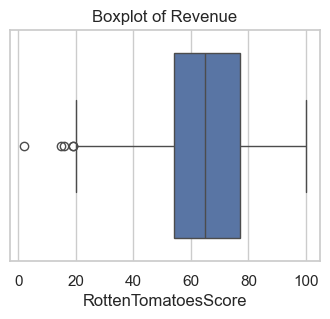

In [51]:
plt.figure(figsize=(4,3))
sns.boxplot(x=df['RottenTomatoesScore'])
plt.title("Boxplot of Revenue")
plt.show()

Points outside the whiskers represent potential outliers.
These extreme revenue values may influence model predictions.

### Detect Outliers using IQR
**Method: Interquartile Range (IQR)**

The IQR method defines outliers as values outside:

`Q1 - 1.5×IQR`  and  `Q3 + 1.5×IQR`

In [52]:
Q1 = df['RottenTomatoesScore'].quantile(0.25)
Q3 = df['RottenTomatoesScore'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['RottenTomatoesScore'] < lower) | (df['RottenTomatoesScore'] > upper)]
outliers.head(15)

,MovieID,Title,Genre,ReleaseYear,ReleaseDate,Country,RottenTomatoesScore,NumVotesIMDb,NumVotesRT
380,381.0,Space,Drama,2004.0,2004-09-14,South Korea,16.0,4807.0,1121.0
382,383.0,Control sell fast,Horror,2015.0,2015-07-22,USA,19.0,1102.0,75.0
403,404.0,Chance interest,Romance,1976.0,1976-11-28,USA,15.0,1824.0,913.0
722,723.0,Store send maybe,Horror,1995.0,1995-03-02,USA,19.0,2438.0,543.0
827,828.0,Short always,Comedy,2024.0,2024-05-31,USA,2.0,4756.0,50.0


The output displays records considered extreme based on statistical boundaries.
These may be valid high-value transactions or potential data errors.

### Remove Outliers


In [53]:
df_no_outliers = df[(df['RottenTomatoesScore'] >= lower) & (df['RottenTomatoesScore'] <= upper)]
print("Original shape: ",df.shape)
print("After removing outliers: ",df_no_outliers.shape)

Original shape:  (923, 9)
After removing outliers:  (918, 9)


### Capping Outliers (Percentile Method)


In [54]:
lower_cap = df['RottenTomatoesScore'].quantile(0.05)
upper_cap = df['RottenTomatoesScore'].quantile(0.95)

df_capped = df.copy()
df_capped['RottenTomatoesScore'] = df_capped['RottenTomatoesScore'].clip(lower_cap, upper_cap)

## 5. Data Transformation – Normalization

### Min-Max Normalization


In [ ]:
df[['RottenTomatoesScore', 'NumVotesRT']].head()

,RottenTomatoesScore,NumVotesRT
0,58.0,10596.0
1,44.0,220.0
2,55.0,7805.0
3,87.0,1751.0
5,100.0,229.0


In [57]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df[['RottenTomatoesScore', 'NumVotesRT']].copy()

df_scaled[['RottenTomatoesScore', 'NumVotesRT']] = scaler.fit_transform(df_scaled)

df_scaled.head()

,RottenTomatoesScore,NumVotesRT
0,0.571429,0.060084
1,0.428571,0.000969
2,0.540816,0.044183
3,0.867347,0.009691
5,1.000000,0.001020


After applying Min-Max normalization, all numerical values are scaled to the range between 0 and 1.

The smallest value in each feature becomes 0, and the largest becomes 1.
All other values are proportionally mapped between these two limits.

### Z-Score Normalization

In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = df[['RottenTomatoesScore', 'NumVotesRT']].copy()

df_standardized[['RottenTomatoesScore', 'NumVotesRT']] = scaler.fit_transform(df_standardized)

df_standardized.head()

,RottenTomatoesScore,NumVotesRT
0,-0.373967,0.852089
1,-1.165257,-0.229536
2,-0.543529,0.561147
3,1.265132,-0.069940
5,1.999901,-0.228597


## Check Correlation Before Applying PCA


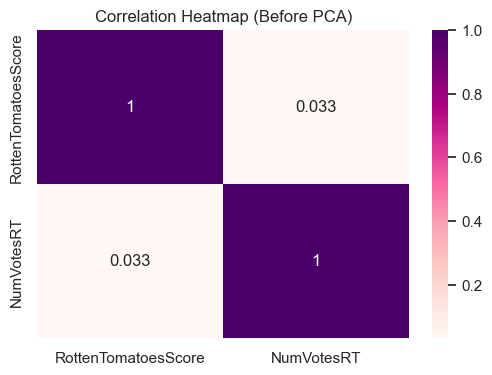

In [60]:
plt.figure(figsize=(6,4))
sns.heatmap(df_standardized[['RottenTomatoesScore','NumVotesRT']].corr(), 
            annot=True, cmap="RdPu")
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

The diagonal values are 1 because each feature is perfectly correlated with itself.
The correlation between `RottenTomatoesScore` and ` NumVotesRT` is approximately *0.033*.
Since correlation is close to 0, it indicates that there is almost no linear relationship between the 2 features.
So the benefit of dimensionality reduction in this case may be limited.

## 6. Data Reduction – Principal Component Analysis (PCA)



### Visual Intuition



In [61]:
from sklearn.decomposition import PCA

X = df_standardized[['RottenTomatoesScore', 'NumVotesRT']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.51656823 0.48343177]


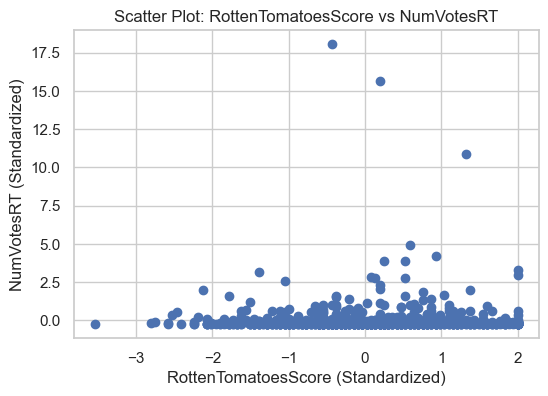

In [65]:

plt.figure(figsize=(6,4))
plt.scatter(df_standardized['RottenTomatoesScore'], df_standardized['NumVotesRT'])
plt.xlabel("RottenTomatoesScore (Standardized)")
plt.ylabel("NumVotesRT (Standardized)")
plt.title("Scatter Plot: RottenTomatoesScore vs NumVotesRT")
plt.show()

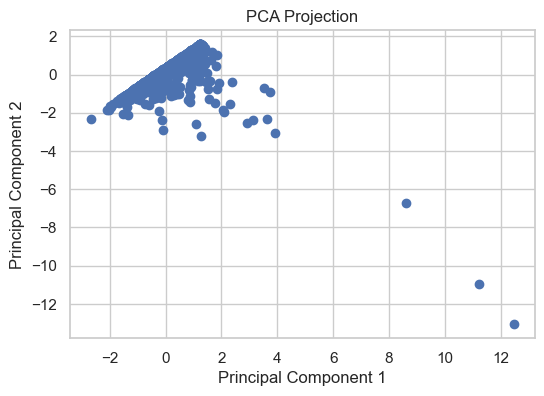

In [64]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()